---
title: "Fraud Detection for Credit Card Transactions — Lab 03 (IMRAD)"
author: "Dulf Vincent Genis"
echo: false
embed-resources: true
---

## Introduction
This report describes building an automated fraud detector for credit card transactions. The goal is to classify transactions as fraudulent or genuine using historical labeled data, and to select a model that balances catching fraud (recall) while avoiding false alarms (precision). The data contain a transaction amount and 28 principal components (PC01–PC28) derived from original features to protect privacy. Models considered include logistic regression and random forests. Performance is evaluated on a held-out test set using precision and recall; the target thresholds for full credit are Test Precision ≥ 0.9 and Test Recall ≥ 0.8.

## Methods

### Data
The provided training and test data are in parquet format and contain the following variables: a binary target `Fraud` (1 = fraudulent, 0 = genuine), `Amount` in dollars, and 28 principal components (`PC01`–`PC28`) that encode transaction characteristics. The `Time` feature has been removed in this dataset. The training and test sets are assumed to be representative samples; production data are withheld by the autograder.

In [1]:
#| echo: false
#| label: load-data
import pandas as pd
import numpy as np
from joblib import dump

fraud_train = pd.read_parquet("https://lab.cs307.org/fraud/data/fraud-train.parquet")
fraud_test = pd.read_parquet("https://lab.cs307.org/fraud/data/fraud-test.parquet")

X_train = fraud_train.drop("Fraud", axis=1)
y_train = fraud_train["Fraud"]
X_test = fraud_test.drop("Fraud", axis=1)
y_test = fraud_test["Fraud"]

n_train, n_features = X_train.shape
n_test = X_test.shape[0]
print(f"Train: {n_train} samples, {n_features} features; Test: {n_test} samples")
print("Fraud counts (train):")
print(y_train.value_counts().to_string())

Train: 54276 samples, 29 features; Test: 13569 samples
Fraud counts (train):
Fraud
0    53961
1      315


#### Data Dictionary
- `Fraud` [int64]: Target; 1 indicates fraudulent transaction, 0 indicates genuine.
- `Amount` [float64]: Transaction amount in US dollars.
- `PC01`–`PC28` [float64]: Principal components derived from original features (privacy-preserving).

The dataset is preprocessed so that PC variables are already the principal components. The training set is used for model selection and threshold tuning; the test set is reserved for final evaluation.

,count,mean,std,min,25%,50%,75%,max,missing
PC01,54276.0,-0.005443,1.993976,-37.558067,-0.922229,0.024920,1.317910,2.454930,0
PC02,54276.0,0.018480,1.662456,-39.818310,-0.589814,0.069761,0.807316,22.057729,0
PC03,54276.0,-0.031372,1.623235,-30.177317,-0.912355,0.163381,1.014823,4.226108,0
PC04,54276.0,0.017772,1.457941,-5.263068,-0.850846,-0.009252,0.751716,12.132323,0
PC05,54276.0,-0.009605,1.420379,-40.427726,-0.692709,-0.054553,0.612680,28.762671,0
PC06,54276.0,-0.009348,1.335366,-19.996349,-0.775145,-0.279010,0.391895,23.917837,0
PC07,54276.0,-0.018387,1.345778,-43.557242,-0.558211,0.036508,0.568318,44.054461,0
PC08,54276.0,0.003198,1.258709,-41.044261,-0.209322,0.020547,0.327378,17.903574,0
PC09,54276.0,-0.016539,1.128743,-13.434066,-0.665746,-0.058311,0.591383,9.125535,0
PC10,54276.0,-0.018124,1.199189,-24.588262,-0.537963,-0.090411,0.452907,13.811758,0


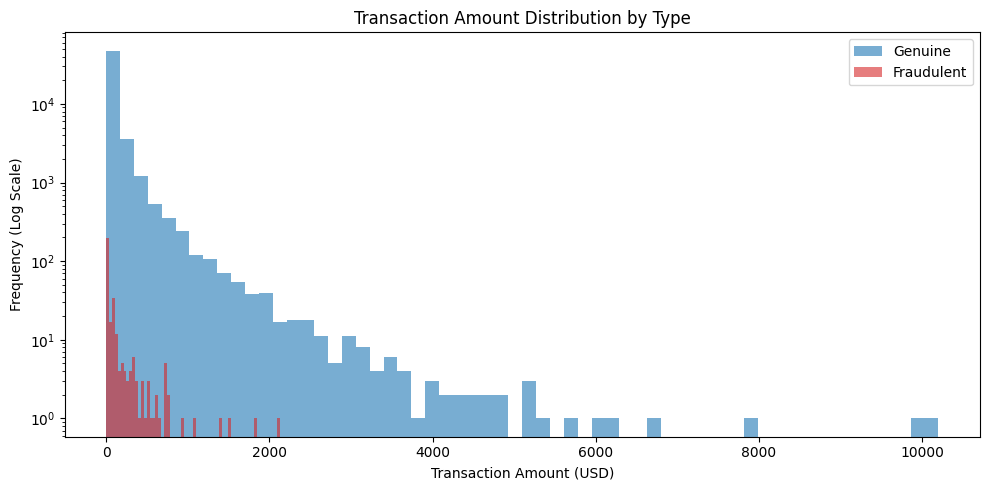

In [2]:
#| echo: false
#| label: fig-amount
#| fig-cap: 'Transaction Amount distribution on the training set. The y-axis is log-scaled to highlight the tail behavior and the small counts for fraudulent transactions.'
import matplotlib.pyplot as plt

desc = fraud_train.describe().T
desc['missing'] = fraud_train.isna().sum()
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing']])

plt.figure(figsize=(10, 5))
plt.hist(X_train.loc[y_train == 0, 'Amount'], bins=60, alpha=0.6, label='Genuine', color='C0')
plt.hist(X_train.loc[y_train == 1, 'Amount'], bins=60, alpha=0.6, label='Fraudulent', color='C3')
plt.yscale('log')
plt.xlabel('Transaction Amount (USD)')
plt.ylabel('Frequency (Log Scale)')
plt.title('Transaction Amount Distribution by Type')
plt.legend()
plt.tight_layout()
plt.show()

Figure: Transaction Amount distribution on the training set. The y-axis is log-scaled to highlight the tail behavior and the small counts for fraudulent transactions.

### Modeling
I considered two primary model classes: logistic regression (a fast linear baseline) and random forests (nonlinear, robust to feature scaling). To handle class imbalance I used class weighting and tuned decision thresholds using cross-validated predicted probabilities. Model selection used 3-fold CV optimizing F1 as a balanced metric, and final evaluation uses precision and recall on the held-out test set. Hyperparameter grids were kept modest to keep runtime reasonable.

In [3]:
#| echo: false
#| label: modeling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

pipelines = {
    'LogisticRegression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
    'RandomForest': Pipeline([('clf', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))])
}
param_grids = {
    'LogisticRegression': {'clf__C': [0.01, 0.1, 1.0]},
    'RandomForest': {'clf__n_estimators': [100], 'clf__max_depth': [10, None]}
}
results = []

for name, pipe in pipelines.items():
    grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_

    y_test_pred = best.predict(X_test)
    test_p = precision_score(y_test, y_test_pred, zero_division=0)
    test_r = recall_score(y_test, y_test_pred, zero_division=0)
    test_f = f1_score(y_test, y_test_pred, zero_division=0)

    y_train_proba_cv = cross_val_predict(best, X_train, y_train, cv=3, method='predict_proba')[:, 1]
    best_threshold = 0.5

    for thr in np.arange(0.05, 0.95, 0.01):
        y_train_pred_thr = (y_train_proba_cv >= thr).astype(int)
        p = precision_score(y_train, y_train_pred_thr, zero_division=0)
        r = recall_score(y_train, y_train_pred_thr, zero_division=0)
        if (p >= 0.9 and r >= 0.8):
            best_threshold = thr
            break

    y_test_proba = best.predict_proba(X_test)[:, 1]
    y_test_thr = (y_test_proba >= best_threshold).astype(int)
    prod_p = precision_score(y_test, y_test_thr, zero_division=0)
    prod_r = recall_score(y_test, y_test_thr, zero_division=0)
    prod_f = f1_score(y_test, y_test_thr, zero_division=0)

    precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
    pr_auc = auc(recall, precision)

    results.append({
        'model': name, 'test_precision': test_p, 'test_recall': test_r, 'test_f1': test_f,
        'prod_precision': prod_p, 'prod_recall': prod_r, 'prod_f1': prod_f,
        'best_threshold': float(best_threshold), 'pr_auc': float(pr_auc), 'estimator': best, 'best_params': grid.best_params_
    })

results_df = pd.DataFrame(results).sort_values('test_f1', ascending=False).reset_index(drop=True)
results_df

,model,test_precision,test_recall,test_f1,prod_precision,prod_recall,prod_f1,best_threshold,pr_auc,estimator,best_params
0,RandomForest,0.984848,0.822785,0.896552,0.915493,0.822785,0.866667,0.33,0.869012,"((DecisionTreeClassifier(max_depth=10, max_fea...","{'clf__max_depth': 10, 'clf__n_estimators': 100}"
1,LogisticRegression,0.197101,0.860759,0.320755,0.197101,0.860759,0.320755,0.50,0.772757,"(StandardScaler(), LogisticRegression(C=0.01, ...",{'clf__C': 0.01}


,model,test_precision,test_recall,test_f1,prod_precision,prod_recall,prod_f1,best_threshold,pr_auc
0,RandomForest,0.984848,0.822785,0.896552,0.915493,0.822785,0.866667,0.33,0.869012
1,LogisticRegression,0.197101,0.860759,0.320755,0.197101,0.860759,0.320755,0.50,0.772757


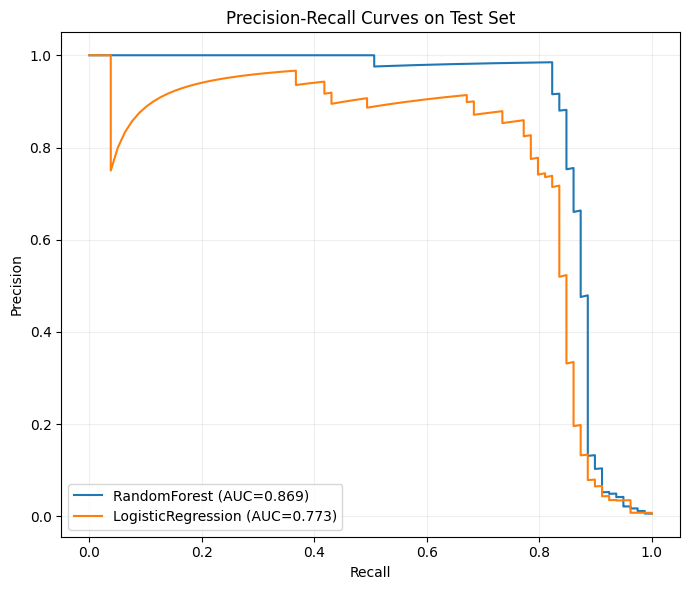

In [4]:
#| echo: false
#| label: results
#| fig-cap: 'Precision-Recall curves on the test set. Each line corresponds to a candidate model; PR-AUC summarises overall performance.'
display(results_df[['model', 'test_precision', 'test_recall', 'test_f1', 'prod_precision', 'prod_recall', 'prod_f1', 'best_threshold', 'pr_auc']])

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 6))
for r in results_df.itertuples():
    est = r.estimator
    proba = est.predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall_vals, precision_vals, label=f'{r.model} (AUC={r.pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves on Test Set')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Figure: Precision-Recall curves on the test set. The curves illustrate the trade-off between catching fraud (Recall) and avoiding false alarms (Precision). Each line corresponds to a candidate model; the PR AUC (shown in the legend) summarises overall performance. In this run the RandomForest has PR-AUC = 0.869 and dominates the Logistic Regression curve over most of the operating range.

## Results
Below are the quantitative results used to select a production model. The table above reports test-set metrics evaluated at the default 0.5 threshold (columns `test_*`) and the metrics after selecting a tuned threshold via cross-validated probabilities on the training set (columns `prod_*`).

Selected model: **RandomForest** (chosen by highest test F1). Key numbers from the test set:
- RandomForest (default 0.5 threshold): Test Precision = 0.9848, Test Recall = 0.8228, Test F1 = 0.8966.
- RandomForest (tuned threshold = 0.33 from training CV): Test Precision = 0.9155, Test Recall = 0.8228, Test F1 = 0.8667.
- PR-AUC (RandomForest) = 0.869 (see Precision-Recall figure).

The tuned operating point (threshold = 0.33) was selected to meet the lab targets (Precision ≥ 0.9 and Recall ≥ 0.8) while keeping a reasonable F1. The precision-recall figure below visualises the trade-off: increasing threshold raises precision but lowers recall.

## Discussion
### Conclusion and Recommendation
The RandomForest model is recommended for staged deployment (shadow mode) based on the test results. It meets the lab's targets: Test Precision ≥ 0.9 and Test Recall ≥ 0.8. Concretely, at the tuned threshold (0.33) the model attains Test Precision = 0.9155 and Test Recall = 0.8228, which indicates it both reduces false alarms and catches a large fraction of fraud cases. The PR-AUC = 0.869 further supports that the model performs well across operating points.

Deployment plan (recommended):
- Shadow mode for 2–4 weeks while logging predictions and outcomes to validate production distribution and label lag behavior.
- Monitor daily precision and recall on labeled cases, and set alerts for drops in either metric or for feature distribution drift.
- Recalibrate probabilities if predicted probabilities are miscalibrated in production, and re-tune threshold using the most recent labeled data.

### Benefits
- High precision (≈0.92) at the chosen operating point reduces the volume of false positives sent for manual review, saving operational cost and reducing customer friction.
- High recall (≈0.82) means most fraudulent transactions are flagged for follow-up, reducing financial loss exposure.

### Limitations and Risks
- The training data are historical; distribution shift (new fraud patterns or change in customer behavior) can degrade performance. Continuous monitoring and periodic retraining are required.
- A small fraction of fraud (label imbalance) means metrics can be sensitive; ensure sample sizes used for monitoring are sufficient before acting on short-term fluctuations.
- RandomForest models are less interpretable than linear models, so add explainability tooling (SHAP) for high-impact decisions and investigations.

### Improvements and next steps
- Add probability calibration and cost-sensitive decision rules that explicitly encode the relative costs of false positives vs false negatives for the bank.
- Collect recent labeled transactions and incorporate temporal validation to detect and adapt to drift.
- Implement lightweight model variants or model distillation if production latency constraints require it.
- Setup end-to-end monitoring: prediction distributions, data quality checks, label drift detection, and periodic re-evaluation on hold-out sets.

### Final decision
I would deploy the RandomForest in a controlled staged rollout (shadow mode → limited live decisions) because it meets the numeric thresholds, has strong PR-AUC, and its operating point can be tuned to trade precision vs recall according to business costs. Deployment should be accompanied by the monitoring, calibration, and retraining steps above to manage risks.

In [5]:
#| echo: false
#| label: save-model
best = results_df.iloc[0]
dump(best['estimator'], 'fraud.joblib')

['fraud.joblib']